# Part 1 - Classical Classification

In [1]:
import os, numpy as np, matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

p='../splits/'
print(os.listdir(p))

# Load indices
idx_data = np.load(p+'splits.npz')
train_idx = idx_data['train_idx']
val_idx = idx_data['val_idx']
print("train_idx", train_idx.shape, "val_idx", val_idx.shape)

# Load full Fashion-MNIST (70k images) from Hub's data or openml
# Try Hub's local copy first
try:
    # Common Hub locations
    import pathlib
    for path in ['/opt/data/fashion-mnist/', '../data/', '../../data/']:
        if os.path.exists(path):
            print("Checking", path, os.listdir(path)[:10])
except:
    pass

# Use openml - this is 70k images, will take 30 sec first time
from sklearn.datasets import fetch_openml
print("Downloading Fashion-MNIST from openml... (once)")
fmnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False, parser='auto')
X_all = fmnist.data.astype('float32')/255.0
y_all = fmnist.target.astype(int)
print("Full dataset", X_all.shape, y_all.shape)

X_train = X_all[train_idx]; y_train = y_all[train_idx]
X_val = X_all[val_idx]; y_val = y_all[val_idx]

# For test, use remaining or split
# If you have test_idx in future, but for now use 10k leftover
all_idx = np.arange(len(X_all))
mask = np.ones(len(X_all), dtype=bool)
mask[train_idx] = False
mask[val_idx] = False
remaining = np.where(mask)[0]
X_test = X_all[remaining[:10000]]; y_test = y_all[remaining[:10000]]

class_names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
print("DONE:", X_train.shape, X_val.shape, X_test.shape)

['splits.npz']
train_idx (50000,) val_idx (10000,)
Full dataset (70000, 784) (70000,)
DONE: (50000, 784) (10000, 784) (10000, 784)


## 1.1 Models

In [2]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
pred_knn=knn.predict(X_val)
logreg=LogisticRegression(max_iter=1000)
logreg.fit(X_train,y_train)
pred_lr=logreg.predict(X_val)
print('KNN',accuracy_score(y_val,pred_knn))
print('LogReg',accuracy_score(y_val,pred_lr))

KNN 0.8595
LogReg 0.8616


## 1.2 Metrics

In [3]:
print(classification_report(y_val,pred_knn,target_names=class_names))
print(classification_report(y_val,pred_lr,target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.78      0.88      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.73      0.81      0.77      1000
       Dress       0.91      0.86      0.88      1000
        Coat       0.77      0.75      0.76      1000
      Sandal       1.00      0.82      0.90      1000
       Shirt       0.70      0.62      0.66      1000
     Sneaker       0.88      0.95      0.91      1000
         Bag       0.98      0.95      0.96      1000
  Ankle boot       0.89      0.97      0.93      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

              precision    recall  f1-score   support

 T-shirt/top       0.80      0.84      0.82      1000
     Trouser       0.97      0.97      0.97      1000
    Pullover       0.77      0.77      0.77      1000
       Dress       0.87 

## 1.3 Error analysis

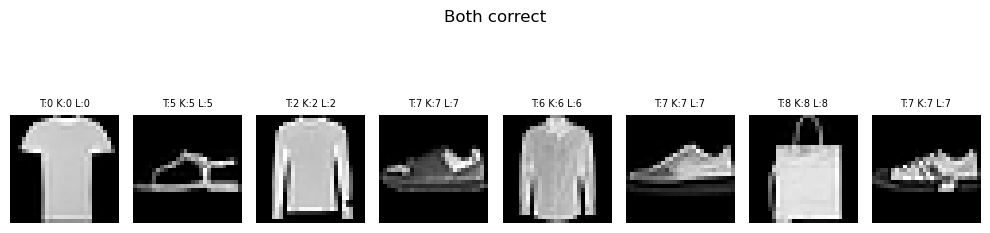

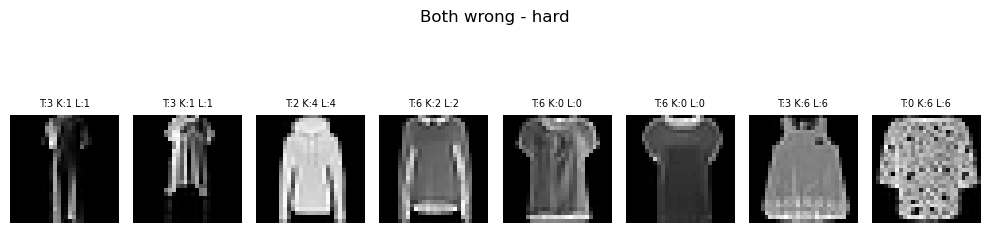

In [4]:
def show(idxs,title):
    plt.figure(figsize=(10,3))
    for i, idx in enumerate(idxs[:8]):
        plt.subplot(1,8,i+1)
        plt.imshow(X_val[idx].reshape(28,28),cmap='gray')
        plt.title(f"T:{y_val[idx]} K:{pred_knn[idx]} L:{pred_lr[idx]}",fontsize=7)
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

correct=np.where((pred_knn==y_val)&(pred_lr==y_val))[0]
incorrect=np.where((pred_knn!=y_val)&(pred_lr!=y_val))[0]
show(correct,'Both correct')
show(incorrect,'Both wrong - hard')

## 1.4 Complexity

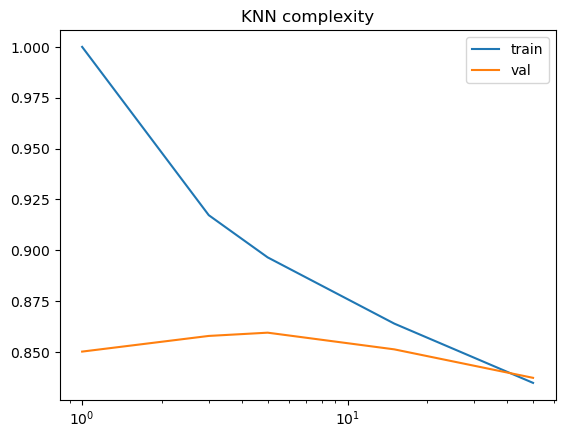

In [5]:
ks=[1,3,5,15,50]
tr=[];va=[]
for k in ks:
 m=KNeighborsClassifier(n_neighbors=k)
 m.fit(X_train,y_train)
 tr.append(accuracy_score(y_train,m.predict(X_train)))
 va.append(accuracy_score(y_val,m.predict(X_val)))
plt.plot(ks,tr,label='train');plt.plot(ks,va,label='val')
plt.xscale('log');plt.legend();plt.title('KNN complexity');plt.show()

## 1.5 Decisions and Costs

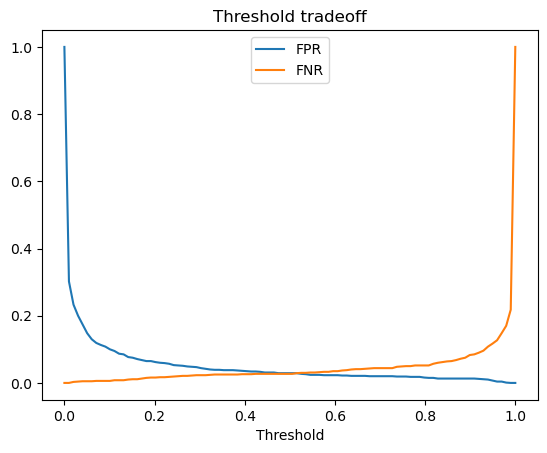

In [6]:
bin_cls=[7,9]
mask_tr=np.isin(y_train,bin_cls);mask_va=np.isin(y_val,bin_cls)
Xtr_b=X_train[mask_tr];ytr_b=(y_train[mask_tr]==9).astype(int)
Xva_b=X_val[mask_va];yva_b=(y_val[mask_va]==9).astype(int)
model=LogisticRegression(max_iter=1000)
model.fit(Xtr_b,ytr_b)
proba=model.predict_proba(Xva_b)[:,1]
ths=np.linspace(0,1,100)
fpr=[];fnr=[]
for t in ths:
 pred=(proba>=t).astype(int)
 FP=np.sum((pred==1)&(yva_b==0));TN=np.sum((pred==0)&(yva_b==0))
 FN=np.sum((pred==0)&(yva_b==1));TP=np.sum((pred==1)&(yva_b==1))
 fpr.append(FP/(FP+TN+1e-9));fnr.append(FN/(FN+TP+1e-9))
plt.plot(ths,fpr,label='FPR');plt.plot(ths,fnr,label='FNR')
plt.xlabel('Threshold');plt.legend();plt.title('Threshold tradeoff');plt.show()